# zedstat example notebook

This notebook is a full, heavily commented walkthrough of the current `zedstat.py` workflow.

It covers:

- loading data and checking the active `zedstat.py` interface
- computing the empirical ROC table
- smoothing with or without convexification
- computing threshold-based measures and analytic bounds
- plotting ROC, PRC, and LR-space curves with low-opacity confidence envelopes
- extracting operating points
- mapping score to **threshold PPV**
- running **held-out isotonic calibration** with bootstrap CIs, Brier score, calibration intercept, and calibration slope
- saving the calibration table and calibration plot through `zedstat.calibration`
- mapping score to **patient-level calibrated probability** using the fitted isotonic model
- computing analytic and optional bootstrap AUC
- estimating the required number of samples as a function of target AUC precision
- plotting required sample size versus allowed AUC deviation
- generating an interpretation table at a chosen false-positive rate

The notebook is written to be robust to small interface differences across nearby `zedstat.py` revisions by checking signatures when needed.


## 1. User parameters

Edit only this cell first. Everything else should run from these settings.

In [1]:
from pathlib import Path
import numpy as np
# ------------------------------------------------------------------
# FILE / COLUMN SETTINGS
# ------------------------------------------------------------------
data_path = Path("./examples_data/PREDICTIONS_NATIONAL_SAMPLE.parquet")   # change to your file
#data_path = Path("./SUICIDALITY-M25504W6WS.parquet")   # change to your file
read_method = "parquet"                 # one of: 'parquet', 'csv'
score_col = "predicted_risk"
label_col = "target"

# ------------------------------------------------------------------
# PROBLEM SETTINGS
# ------------------------------------------------------------------
deployment_prevalence = 0.10            # prevalence to use for PPV / NPV style measures
lower_score_is_risk = False             # set True only if smaller score = higher risk

# ------------------------------------------------------------------
# ROC / MEASURE SETTINGS
# ------------------------------------------------------------------
use_convexify = False                   # True => use ROC upper hull before interpolation
smooth_step = 0.001                     # FPR grid spacing for smooth()
precision = 3                           # decimal precision for usample()
alpha = 0.05                            # confidence level parameter
lr_fpr_floor = 0.001                    # censor LR+ / LR- when FPR is below this

# ------------------------------------------------------------------
# CALIBRATION SETTINGS
# ------------------------------------------------------------------
calibration_test_size = 0.25            # held-out test fraction
calibration_n_bins = 100                # number of bins in calibration plot/table
calibration_n_boot = 1000               # bootstrap replicates for held-out calibration metrics
calibration_target_prevalence = None    # None => use observed prevalence; set a float for reweighted deployment prevalence
random_state = 4

# Calibration output files written by zedstat.calibration
calibration_df_path = "calibration_df.csv"
calibration_plot_path = "calibration.pdf"

# ------------------------------------------------------------------
# THRESHOLD / INTERPRETATION SETTINGS
# ------------------------------------------------------------------
example_scores = [0.02, 0.05, 0.10]     # example score values to query
interpret_fpr = 0.01                    # operating point to interpret
interpret_positive_cases = 100
five_yr_survival = None                 # set numeric value if you want NNS

# ------------------------------------------------------------------
# SAMPLE SIZE SETTINGS
# ------------------------------------------------------------------
delta_auc_grid = np.linspace(0.01, 0.10, 10)
target_auc_for_planning = None          # None => use nominal AUC estimated from current data
sample_size_target_auc = None           # None => use current nominal AUC


## 2. Imports and module sanity check

This cell prints the active file path and the signatures of the main entry points.  
That is useful because several earlier copies of `zedstat.py` in this thread had slightly different interfaces.

In [2]:
import inspect
import importlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from zedstat import zedstat
from zedstat import calibration
#importlib.reload(zedstat)
#importlib.reload(calibration)

print("Active zedstat.py:", zedstat.__file__)
print("Active calibration.py:", calibration.__file__)
print("processRoc.__init__ signature:")
print(inspect.signature(zedstat.processRoc.__init__))
print()
print("pipeline signature:")
print(inspect.signature(zedstat.pipeline))


Active zedstat.py: /home/ishanu/.local/lib/python3.12/site-packages/zedstat/zedstat.py
Active calibration.py: /home/ishanu/.local/lib/python3.12/site-packages/zedstat/calibration.py
processRoc.__init__ signature:
(self, df=None, fprcol='fpr', tprcol='tpr', thresholdcol='threshold', prevalence=None, order=2, total_samples=None, positive_samples=None, alpha=0.05, lr_fpr_floor=0.001)

pipeline signature:
(df, risk='predicted_risk', target='target', steps=1000, TARGET=[1], order=3, alpha=0.05, prevalence=0.002, precision=3, convexify=False, lr_fpr_floor=0.001, outfile=None)


## 3. Load the data

This notebook supports parquet and CSV for convenience.

In [3]:
if read_method == "parquet":
    df = pd.read_parquet(data_path)
elif read_method == "csv":
    df = pd.read_csv(data_path)
else:
    raise ValueError("read_method must be 'parquet' or 'csv'")

print(df.shape)
display(df.head())

if score_col not in df.columns:
    raise KeyError(f"Missing score column: {score_col}")

if label_col not in df.columns:
    raise KeyError(f"Missing label column: {label_col}")

print("Columns OK.")

(200000, 11)


,patient_id,age_at_screening,sex,PRESENCE_DX_score,PRESENCE_RX_score,PRESENCE_PROC_score,ODDSRATIO_DX_score,ODDSRATIO_RX_score,ODDSRATIO_PROC_score,predicted_risk,target
0,27509151101,55.0,1,0.010419,0.005127,0.008586,0.018947,0.012582,0.012436,0.029867,0
1,28292924701,62.0,1,0.008668,0.008252,0.010419,0.014291,0.016001,0.022374,0.030038,0
2,3331490401,56.0,1,0.002031,0.005127,0.002035,0.003346,0.012582,0.002874,0.029166,0
3,1771798702,62.0,0,0.006764,0.006385,0.003818,0.011309,0.027785,0.004541,0.029426,0
4,1229711701,69.0,1,0.036014,0.027225,0.029026,0.049672,0.028453,0.046936,0.033235,0


Columns OK.


## 4. Compute the empirical ROC table

`genroc(...)` creates the empirical threshold/FPR/TPR table directly from raw scores and labels.

In [4]:
rf, total_samples, positive_samples = zedstat.genroc(
    df,
    risk=score_col,
    target=label_col,
)

print("total_samples =", total_samples)
print("positive_samples =", positive_samples)
display(rf.head())

total_samples = 200000
positive_samples = 6158


,threshold,fpr,tpr
0,0.341438,0.0,0.000162
1,0.340747,0.0,0.000325
2,0.329822,0.0,0.000650
3,0.329587,0.0,0.001299
4,0.329526,0.0,0.001462


## 5. Build the main `processRoc` object

This block is written to handle both cases:
- newer `zedstat.py` versions where `lr_fpr_floor` is accepted directly in the constructor
- older nearby variants where it is set later with `set_lr_fpr_floor(...)`

In [5]:
proc_sig = inspect.signature(zedstat.processRoc.__init__)

proc_kwargs = dict(
    df=rf,
    prevalence=deployment_prevalence,
    total_samples=total_samples,
    positive_samples=positive_samples,
    alpha=alpha,
)

if "lr_fpr_floor" in proc_sig.parameters:
    proc_kwargs["lr_fpr_floor"] = lr_fpr_floor

zt = zedstat.processRoc(**proc_kwargs)

if hasattr(zt, "set_lr_fpr_floor"):
    zt.set_lr_fpr_floor(lr_fpr_floor)
elif not hasattr(zt, "lr_fpr_floor"):
    # This fallback keeps the notebook usable even if a nearby version
    # stores the threshold as a plain attribute.
    zt.lr_fpr_floor = lr_fpr_floor

print("processRoc object created.")

processRoc object created.


## 6. Smooth the ROC, compute threshold-based measures, and derive analytic bounds

Important notes:

- `convexify=False` means you keep the empirical ROC shape and only interpolate it.
- `convexify=True` means you replace the empirical ROC by its upper hull before interpolation.
- There is only one set of measures in the downstream tables. Convexification is just a preprocessing choice.
- Likelihood ratios are censored when `FPR < lr_fpr_floor`.

In [6]:
zt.smooth(STEP=smooth_step, convexify=use_convexify)
zt.allmeasures(prevalence=deployment_prevalence, interpolate=True)
zt.usample(precision=precision)
zt.getBounds()

perf_df = (
    zt.get()
    .join(zt.df_lim["U"], rsuffix="_upper")
    .join(zt.df_lim["L"], rsuffix="_lower")
)

display(perf_df.head())
print(perf_df.columns.tolist())

,tpr,ppv,acc,npv,LR+,LR-,threshold,tpr_upper,ppv_upper,acc_upper,...,LR+_upper,LR-_upper,threshold_upper,tpr_lower,ppv_lower,acc_lower,npv_lower,LR+_lower,LR-_lower,threshold_lower
fpr,,,,,,,,,,,,,,,,,,,,,
0.000,0.005684,1.000000,0.900568,0.900512,NaN,NaN,0.321476,0.007894,1.000000,0.900789,...,NaN,NaN,0.321476,0.004090,0.958212,0.900391,0.900711,NaN,NaN,0.321476
0.001,0.112895,0.926166,0.910390,0.910195,112.895421,0.887993,0.239798,0.121042,0.938944,0.911322,...,139.345282,0.895676,0.239798,0.105231,0.908426,0.909487,0.910957,91.469629,0.879591,0.239798
0.002,0.171595,0.905061,0.915360,0.915559,85.797662,0.830065,0.211393,0.181216,0.917491,0.916492,...,100.078589,0.839470,0.211393,0.162384,0.890923,0.914250,0.916472,73.510317,0.820269,0.211393
0.003,0.209005,0.885596,0.918200,0.918989,69.668291,0.793375,0.193942,0.219340,0.898035,0.919444,...,79.293217,0.803582,0.193942,0.199033,0.871698,0.916975,0.919980,61.174737,0.782825,0.193942
0.004,0.242509,0.870740,0.920651,0.922081,60.627152,0.760534,0.180486,0.253372,0.882909,0.921981,...,67.952268,0.771343,0.180486,0.231966,0.857097,0.919335,0.923132,54.059037,0.749423,0.180486


['tpr', 'ppv', 'acc', 'npv', 'LR+', 'LR-', 'threshold', 'tpr_upper', 'ppv_upper', 'acc_upper', 'npv_upper', 'LR+_upper', 'LR-_upper', 'threshold_upper', 'tpr_lower', 'ppv_lower', 'acc_lower', 'npv_lower', 'LR+_lower', 'LR-_lower', 'threshold_lower']


## 7. Quick look at the resulting performance table

The combined `perf_df` contains the nominal threshold-level measures and their upper/lower analytic bounds.

In [7]:
summary_cols = [c for c in ["threshold", "tpr", "ppv", "npv", "LR+", "LR-", "tpr_upper", "ppv_upper", "tpr_lower", "ppv_lower"] if c in perf_df.columns]
display(perf_df[summary_cols].head(10))

,threshold,tpr,ppv,npv,LR+,LR-,tpr_upper,ppv_upper,tpr_lower,ppv_lower
fpr,,,,,,,,,,
0.000,0.321476,0.005684,1.000000,0.900512,NaN,NaN,0.007894,1.000000,0.004090,0.958212
0.001,0.239798,0.112895,0.926166,0.910195,112.895421,0.887993,0.121042,0.938944,0.105231,0.908426
0.002,0.211393,0.171595,0.905061,0.915559,85.797662,0.830065,0.181216,0.917491,0.162384,0.890923
0.003,0.193942,0.209005,0.885596,0.918989,69.668291,0.793375,0.219340,0.898035,0.199033,0.871698
0.004,0.180486,0.242509,0.870740,0.922081,60.627152,0.760534,0.253372,0.882909,0.231966,0.857097
0.005,0.168805,0.272978,0.858481,0.924910,54.595648,0.730675,0.284244,0.870561,0.261996,0.845378
0.006,0.159648,0.297662,0.846443,0.927206,49.610263,0.706578,0.309205,0.858431,0.286371,0.833553
0.007,0.151648,0.322345,0.836510,0.929519,46.049274,0.682432,0.334126,0.848305,0.310786,0.823889
0.008,0.144538,0.341507,0.825880,0.931310,42.688373,0.663803,0.353447,0.837622,0.329765,0.813385


## 8. Plot ROC, PRC, and LR-space curves with filled bounds

The ROC panel uses the nominal FPR grid directly.  
The PRC and LR panels are drawn as low-opacity polygons between lower and upper curves.

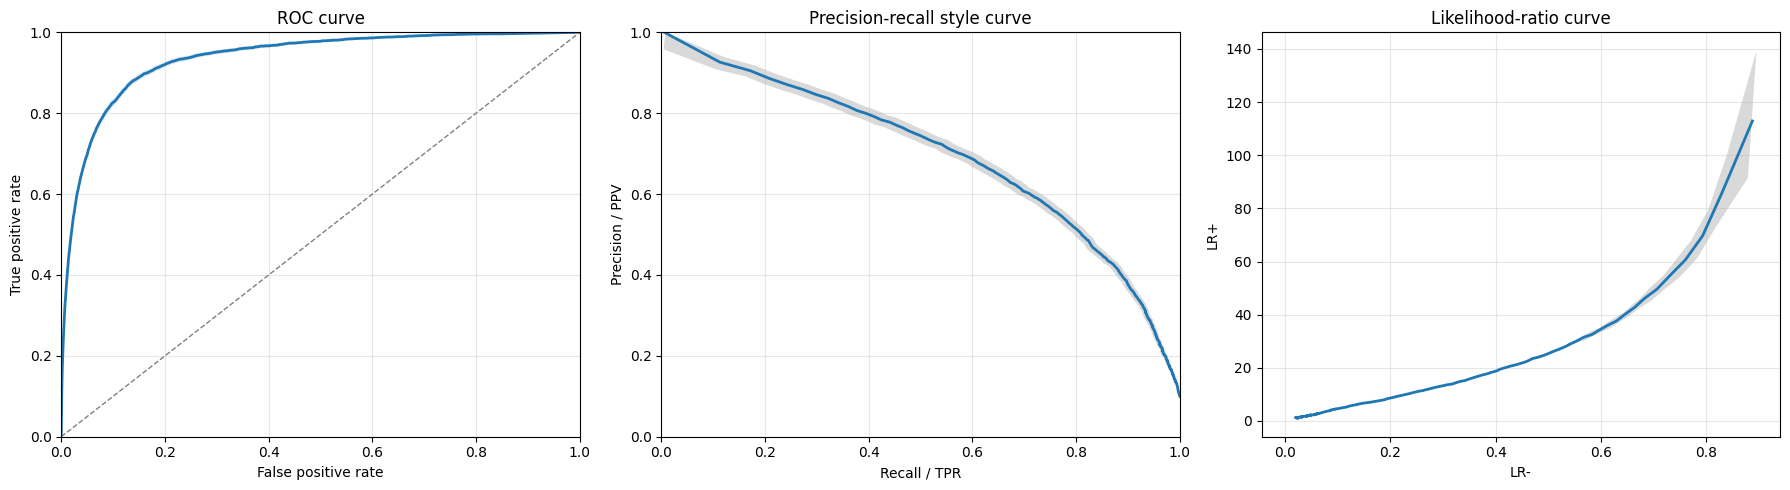

In [8]:
def _as_plot_df(perf_df):
    pf = perf_df.reset_index().copy()
    if "fpr" not in pf.columns:
        pf = pf.rename(columns={pf.columns[0]: "fpr"})
    return pf

def _fill_between_curves(ax, x1, y1, x2, y2, color="k", alpha=0.12, zorder=1):
    x1 = np.asarray(x1, dtype=float)
    y1 = np.asarray(y1, dtype=float)
    x2 = np.asarray(x2, dtype=float)
    y2 = np.asarray(y2, dtype=float)

    m1 = np.isfinite(x1) & np.isfinite(y1)
    m2 = np.isfinite(x2) & np.isfinite(y2)

    x1, y1 = x1[m1], y1[m1]
    x2, y2 = x2[m2], y2[m2]

    if len(x1) < 2 or len(x2) < 2:
        return

    o1 = np.argsort(x1)
    o2 = np.argsort(x2)

    x1, y1 = x1[o1], y1[o1]
    x2, y2 = x2[o2], y2[o2]

    poly_x = np.r_[x1, x2[::-1]]
    poly_y = np.r_[y1, y2[::-1]]
    ax.fill(poly_x, poly_y, color=color, alpha=alpha, linewidth=0, zorder=zorder)

pf = _as_plot_df(perf_df)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# -------------------------
# ROC: FPR vs TPR
# -------------------------
roc = pf[["fpr", "tpr", "tpr_lower", "tpr_upper"]].copy().sort_values("fpr")
axes[0].fill_between(roc["fpr"], roc["tpr_lower"], roc["tpr_upper"], alpha=0.15)
axes[0].plot(roc["fpr"], roc["tpr"], lw=2)
axes[0].plot([0, 1], [0, 1], "--", color="0.5", lw=1)
axes[0].set_xlabel("False positive rate")
axes[0].set_ylabel("True positive rate")
axes[0].set_title("ROC curve")
axes[0].set_xlim(0, 1)
axes[0].set_ylim(0, 1)
axes[0].grid(alpha=0.3)

# -------------------------
# PRC: Recall (=TPR) vs Precision (=PPV)
# -------------------------
pr = pf[["tpr", "ppv", "tpr_lower", "ppv_lower", "tpr_upper", "ppv_upper"]].copy()
_fill_between_curves(
    axes[1],
    pr["tpr_lower"], pr["ppv_lower"],
    pr["tpr_upper"], pr["ppv_upper"],
    alpha=0.15,
)
pr_nom = pr[["tpr", "ppv"]].replace([np.inf, -np.inf], np.nan).dropna().sort_values("tpr")
axes[1].plot(pr_nom["tpr"], pr_nom["ppv"], lw=2)
axes[1].set_xlabel("Recall / TPR")
axes[1].set_ylabel("Precision / PPV")
axes[1].set_title("Precision-recall style curve")
axes[1].set_xlim(0, 1)
axes[1].set_ylim(0, 1)
axes[1].grid(alpha=0.3)

# -------------------------
# LR-space: LR- vs LR+
# -------------------------
lr = pf[["LR-", "LR+", "LR-_lower", "LR+_lower", "LR-_upper", "LR+_upper"]].copy()
lr = lr.replace([np.inf, -np.inf], np.nan)

_fill_between_curves(
    axes[2],
    lr["LR-_lower"], lr["LR+_lower"],
    lr["LR-_upper"], lr["LR+_upper"],
    alpha=0.15,
)
lr_nom = lr[["LR-", "LR+"]].dropna()
lr_nom = lr_nom[(lr_nom["LR-"] > 0) & (lr_nom["LR+"] > 0)].sort_values("LR-")
axes[2].plot(lr_nom["LR-"], lr_nom["LR+"], lw=2)
axes[2].set_xlabel("LR-")
axes[2].set_ylabel("LR+")
axes[2].set_title("Likelihood-ratio curve")
axes[2].grid(alpha=0.3, which="both")

plt.tight_layout()
plt.show()

## 9. Query threshold-level PPV at selected scores

This is **not** patient-level calibrated probability.  
It is the PPV associated with the threshold equal to that score.

In [9]:
threshold_ppv = zt.score_to_threshold_ppv(
    example_scores,
    regen=False,   # use the performance table already built above
)

threshold_ppv_df = pd.DataFrame({
    "score": example_scores,
    "threshold_ppv": np.asarray(threshold_ppv, dtype=float),
})

display(threshold_ppv_df)

,score,threshold_ppv
0,0.02,0.100000
1,0.05,0.523255
2,0.10,0.738022


## 10. Run held-out isotonic calibration analysis

This path now uses `from zedstat import calibration` rather than the older
`zt.fit_score_calibration(...)` interface.

The workflow is:

1. split the data into train and test sets  
2. fit isotonic calibration on the training split only  
3. evaluate on the held-out test set  
4. report AUC, Brier score, calibration intercept, calibration slope, and bootstrap confidence intervals  
5. save the calibration table and calibration plot to the filenames specified above

The most important user-tunable parameters here are:

- `calibration_test_size`
- `calibration_n_bins`
- `calibration_n_boot`
- `calibration_df_path`
- `calibration_plot_path`


In [ ]:
res = calibration.heldout_isotonic_calibration_with_bootstrap(
    df,
    score_col=score_col,
    label_col=label_col,
    test_size=calibration_test_size,
    random_state=random_state,
    lower_score_is_risk=lower_score_is_risk,
    target_prevalence=calibration_target_prevalence,
    n_bins=calibration_n_bins,
    n_boot=calibration_n_boot,
    calibration_df_path=calibration_df_path,
    plot=calibration_plot_path,
)

cal_summary = res["summary"]
cal_df = res["calibration_table"]

print(cal_summary)
display(cal_df)


 59%|███████████████████████▊                | 594/1000 [01:32<00:58,  6.89it/s]

## 11. Check the saved calibration plot

The calibration helper writes the plot directly to `calibration_plot_path`.
If the file is an image, this cell will also preview it inline.


In [ ]:
from pathlib import Path

plot_path = res.get("plot_file", None)

if plot_path is None:
    print("No calibration plot file was written.")
else:
    plot_path = Path(plot_path)
    print("Calibration plot saved to:", plot_path.resolve())
    if plot_path.suffix.lower() in {".png", ".jpg", ".jpeg"}:
        from IPython.display import Image, display
        display(Image(filename=str(plot_path)))


## 12. Query calibrated patient-level probability at selected scores

The held-out calibration workflow returns the fitted isotonic model in
`res["iso_model"]`. This cell uses that mapping to convert example scores to
calibrated probabilities.


In [ ]:
score_array = np.asarray(example_scores, dtype=float)
score_for_iso = -score_array if lower_score_is_risk else score_array

calibrated_probs = res["iso_model"].predict(score_for_iso)

calibrated_df = pd.DataFrame({
    "score": example_scores,
    "calibrated_probability": np.asarray(calibrated_probs, dtype=float),
})

display(calibrated_df)


## 13. Analytic AUC and optional bootstrap AUC

The analytic AUC uses the built-in closed-form approximation.  
The bootstrap AUC uses the calibration re-sampling to estimate 

In [ ]:
auc_nominal, auc_upper, auc_lower = zt.auc()
print("Analytic AUC")
print("nominal =", auc_nominal)
print("upper   =", auc_upper)
print("lower   =", auc_lower)

In [ ]:
res["summary"].set_index('variable').loc['auc_calibrated_test']

## 14. Operating-zone extraction

This identifies operating points that simultaneously satisfy:
- `LR+ > LRplus`
- `LR- < LRminus`

and then reports one high-precision and one high-sensitivity endpoint per requested `n`.

In [ ]:
zt.operating_zone(n=1, LRplus=10, LRminus=0.6)
display(zt._operating_zone)

## 15. Interpretation at a chosen false-positive rate

This block converts a chosen operating point into expected flag counts, false alarms, and missed cases for a hypothetical number of positives.

In [ ]:
rf_interpret, txt_interpret, resdf_interpret = zt.interpret(
    fpr=interpret_fpr,
    number_of_positives=interpret_positive_cases,
    five_yr_survival=five_yr_survival,
    factor=1,
)

display(rf_interpret)
display(resdf_interpret)

for line in txt_interpret:
    print(line)

## 16. Sample-size planning for AUC precision

`zt.samplesize(delta_auc=...)` estimates the required number of samples per class under the model's approximation.  
A smaller allowed AUC deviation requires more samples.

If `target_auc_for_planning` is left as `None`, the notebook uses the current nominal AUC.

In [ ]:
planning_auc = auc_nominal if target_auc_for_planning is None else float(target_auc_for_planning)

sample_size_rows = []
for d in delta_auc_grid:
    req = zt.samplesize(delta_auc=d, target_auc=planning_auc, alpha=.05, prevalence=.1)
    sample_size_rows.append({
        "delta_auc": d,
        "required_samples": req,
    })

sample_size_df = pd.DataFrame(sample_size_rows).sort_values("delta_auc", ascending=False)
display(sample_size_df)
sample_size_df.to_csv('sample_size_df.csv')

## 17. Plot required sample size versus allowed AUC deviation

The x-axis is the maximum tolerated AUC error.  
The y-axis is the required number of samples **per class** under the approximation used by `zedstat.samplesize(...)`.

In [ ]:
plt.figure(figsize=(6.5, 4.5))
plt.plot(sample_size_df["delta_auc"], sample_size_df["required_samples"], marker="o", linewidth=2)
plt.xlabel("Allowed AUC deviation")
plt.ylabel("Required samples")
plt.title(f"Sample-size planning at target AUC = {planning_auc:.4f}")
plt.grid(alpha=0.3)
plt.gca().set_yscale('log')
plt.tight_layout()
plt.show()

## 18. Optional direct `pipeline(...)` example

The `pipeline(...)` helper is convenient, but it exposes fewer intermediate objects than the manual path.  
Use the manual path above when you need fine-grained access to all features.

This block is guarded so it only passes parameters that the active `zedstat.py` version actually supports.

In [ ]:
pipe_sig = inspect.signature(zedstat.pipeline)

pipe_kwargs = dict(
    df=df,
    risk=score_col,
    target=label_col,
    prevalence=deployment_prevalence,
    precision=precision,
)

if "convexify" in pipe_sig.parameters:
    pipe_kwargs["convexify"] = use_convexify
if "lr_fpr_floor" in pipe_sig.parameters:
    pipe_kwargs["lr_fpr_floor"] = lr_fpr_floor
if "alpha" in pipe_sig.parameters:
    pipe_kwargs["alpha"] = alpha

perf_df_pipeline, auc_pipeline = zedstat.pipeline(**pipe_kwargs)

print("pipeline AUC tuple:")
print(auc_pipeline)

display(perf_df_pipeline.head())

## 19. Practical notes

- Use `score_to_threshold_ppv(...)` when you want **post-test yield at a threshold**.
- Use `from zedstat import calibration` followed by `heldout_isotonic_calibration_with_bootstrap(...)` when you want **held-out patient-level calibration assessment**, including AUC, Brier score, calibration intercept, calibration slope, and bootstrap confidence intervals.
- Use `res["iso_model"]` when you want to map a raw score to a **patient-level calibrated probability** after fitting the calibration model.
- Use the manual `processRoc` path when you want complete control over convexification, LR censoring, analytic bounds, and bootstrap AUC.
- Use `pipeline(...)` only for quick one-line summaries.
